# Tutorial 7.2 - Deep Neural Networks (Regression)

### Purpose



🔘 Problem :Supermarket owners want to predict the prices of goods and merchandise in order to know which branches make more profits and which ones should be developed in order to determine more profit.

🔘 Solving the problem : With the development we are witnessing from artificial intelligence, machine learning models can be used and then trained on a set of training data, then tested on a set of test data, and predicts prices and incomes based on the data to be entered.


### Data description



Invoice id: Computer generated sales slip invoice identification number

Branch: Branch of supercenter (3 branches are available identified by A, B and C).

City: Location of supercenters

Customer type: Type of customers, recorded by Members for customers using member card and Normal for without member card.

Gender: Gender type of customer

Product line: General item categorization groups - Electronic accessories, Fashion accessories, Food and beverages, Health and beauty, Home and lifestyle, Sports and travel

Unit price: Price of each product in $

Quantity: Number of products purchased by customer

Tax: 5% tax fee for customer buying

Total: Total price including tax

Date: Date of purchase (Record available from January 2019 to March 2019)

Time: Purchase time (10am to 9pm)

Payment: Payment used by customer for purchase (3 methods are available – Cash, Credit card and Ewallet)

COGS: Cost of goods sold

Gross margin percentage: Gross margin percentage

Gross income: Gross income

Rating: Customer stratification rating on their overall shopping experience (On a scale of 1 to 10)


In [1]:
import pandas as pd
import matplotlib

### Import data

In [2]:
mydata = pd.read_csv('data/supermarket_sales.csv')

In [3]:
mydata

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


### Describe the data (numerical columns only)

In [4]:
mydata.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

Describe the data for numerical columns:

In [5]:
mydata.describe().style.background_gradient(cmap='Oranges')

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,307.587380,4.761905,15.379369,6.972700
std,26.494628,2.923431,11.708825,245.885335,234.176510,0.000000,11.708825,1.718580
min,10.080000,1.000000,0.508500,10.678500,10.170000,4.761905,0.508500,4.000000
25%,32.875000,3.000000,5.924875,124.422375,118.497500,4.761905,5.924875,5.500000
50%,55.230000,5.000000,12.088000,253.848000,241.760000,4.761905,12.088000,7.000000
75%,77.935000,8.000000,22.445250,471.350250,448.905000,4.761905,22.445250,8.500000
max,99.960000,10.000000,49.650000,1042.650000,993.000000,4.761905,49.650000,10.000000


Describe the data for string-related columns:

In [6]:
mydata.describe(include='O')

C:\Users\yhuas\AppData\Local\Temp\ipykernel_45200\1758626570.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  mydata.describe(include='O')


,Invoice ID,Branch,City,Customer type,Gender,Product line,Date,Time,Payment
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,3,2,2,6,89,506,3
top,750-67-8428,A,Yangon,Member,Female,Fashion accessories,2/7/2019,19:48,Ewallet
freq,1,340,340,501,501,178,20,7,345


### Check if any missing values

In [7]:
mydata.isna().any()

Invoice ID                 False
Branch                     False
City                       False
Customer type              False
Gender                     False
Product line               False
Unit price                 False
Quantity                   False
Tax 5%                     False
Total                      False
Date                       False
Time                       False
Payment                    False
cogs                       False
gross margin percentage    False
gross income               False
Rating                     False
dtype: bool

In [8]:
mydata.isnull().any()

Invoice ID                 False
Branch                     False
City                       False
Customer type              False
Gender                     False
Product line               False
Unit price                 False
Quantity                   False
Tax 5%                     False
Total                      False
Date                       False
Time                       False
Payment                    False
cogs                       False
gross margin percentage    False
gross income               False
Rating                     False
dtype: bool

### Lets do some basic graphing

In [9]:
mydata[['Product line','Quantity']].groupby(['Product line']).mean().sort_values(by='Quantity',ascending=False).style.background_gradient(cmap='Oranges')

,Quantity
Product line,
Electronic accessories,5.711765
Home and lifestyle,5.693750
Health and beauty,5.618421
Sports and travel,5.542169
Food and beverages,5.471264
Fashion accessories,5.067416


<Axes: ylabel='Product line'>

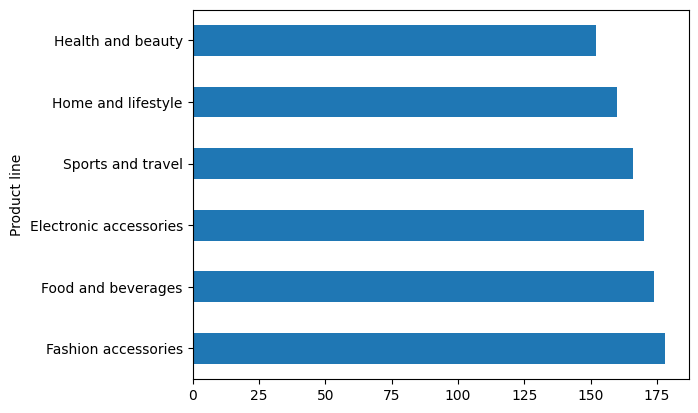

In [10]:
mydata['Product line'].value_counts().plot.barh()

<Axes: ylabel='Product line'>

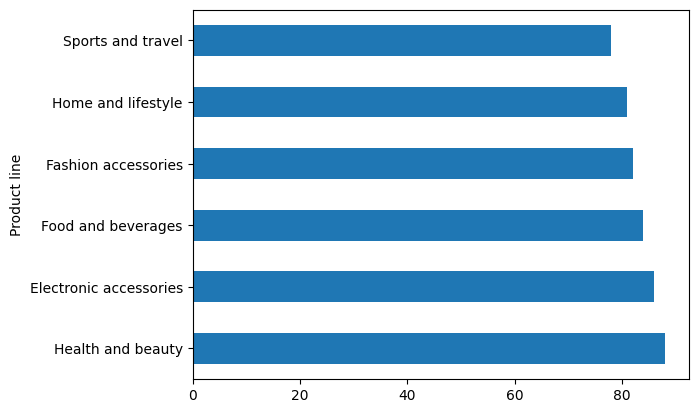

In [11]:
mydata[mydata.Gender == 'Male']['Product line'].value_counts().plot.barh()

<Axes: ylabel='Product line'>

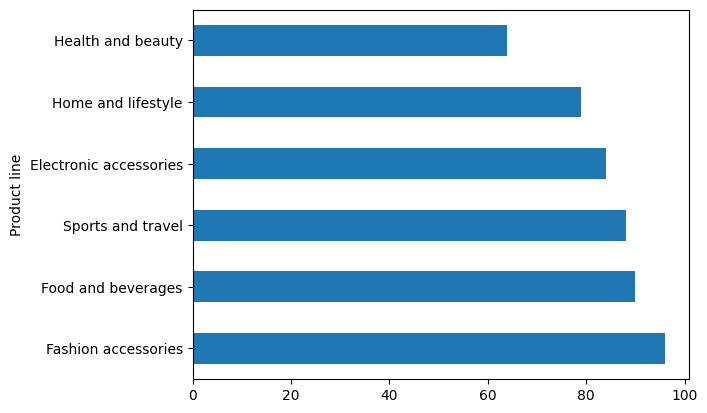

In [12]:
mydata[mydata.Gender == 'Female']['Product line'].value_counts().plot.barh()

## Data Preparation

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

Drop unwanted columns:

In [14]:
mydata = mydata.drop(['Invoice ID','Time','Date'],axis=1)

Transfrom "string" columns into numerical using an encoder

In [15]:
LE=LabelEncoder()

categories=['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for label in categories:
    mydata[label]=LE.fit_transform(mydata[label])

In [16]:
mydata.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating
0,0,2,0,0,3,74.69,7,26.1415,548.9715,2,522.83,4.761905,26.1415,9.1
1,2,1,1,0,0,15.28,5,3.8200,80.2200,0,76.40,4.761905,3.8200,9.6
2,0,2,1,1,4,46.33,7,16.2155,340.5255,1,324.31,4.761905,16.2155,7.4
3,0,2,0,1,3,58.22,8,23.2880,489.0480,2,465.76,4.761905,23.2880,8.4
4,0,2,1,1,5,86.31,7,30.2085,634.3785,2,604.17,4.761905,30.2085,5.3


### Set the objective or target column for prediction

#### Set the objective or target column for prediction
### Lets say, we choose: "Total"

In [17]:
x = mydata.drop('Total', axis=1)

In [18]:
x.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Payment,cogs,gross margin percentage,gross income,Rating
0,0,2,0,0,3,74.69,7,26.1415,2,522.83,4.761905,26.1415,9.1
1,2,1,1,0,0,15.28,5,3.8200,0,76.40,4.761905,3.8200,9.6
2,0,2,1,1,4,46.33,7,16.2155,1,324.31,4.761905,16.2155,7.4
3,0,2,0,1,3,58.22,8,23.2880,2,465.76,4.761905,23.2880,8.4
4,0,2,1,1,5,86.31,7,30.2085,2,604.17,4.761905,30.2085,5.3


In [19]:
y = mydata['Total']

In [20]:
y.head()

0    548.9715
1     80.2200
2    340.5255
3    489.0480
4    634.3785
Name: Total, dtype: float64

### Split data

In [21]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)

In [22]:
x_valid, x_test, y_valid, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

## Deep Learning Model

We are going to use Keras, a deep learning framework (simplified).
Keras is now embedded in Google Tensorflow.

Target column: Total  
Column datatype: Numerical  
Task: Regression  

`!pip install tensorflow`  

In [23]:
import tensorflow as tf

### Define our deep learning model

In [24]:
x_train.shape

(800, 13)

In [25]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input((13,)),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(1)
])

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

### Prepare the optimizers, loss functions and evaluation metrics

In [27]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=[tf.keras.metrics.R2Score()])

### Train the model using the training set (80%)

In [28]:
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 125785.1562 - r2_score: -1.1260
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 64035.5312 - r2_score: -0.0823
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 23658.7832 - r2_score: 0.6001
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5764.9556 - r2_score: 0.9026
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1215.0247 - r2_score: 0.9795
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 703.4305 - r2_score: 0.9881
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 514.6364 - r2_score: 0.9913
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 308.3253 - r2_score: 0.9948
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 161.1254 - r2_score: 0.9973
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 76.2734 - r2_score: 0.9987


In [29]:
model.evaluate(x_train, y_train)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 48.6306 - r2_score: 0.9992  


[48.630645751953125, 0.9991780519485474]

### Evaluate the model on the validation set (10%)

In [31]:
model.evaluate(x_valid, y_valid)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 54.1102 - r2_score: 0.9992


[54.11021041870117, 0.9991692304611206]

### Evaluate the model on the testing set (10%)

In [32]:
model.evaluate(x_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 39.5677 - r2_score: 0.9994


[39.567657470703125, 0.9993906617164612]

### Plotting predicted values vs actual values

In [33]:
test_predictions = model.predict(x_test).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [34]:
import matplotlib.pyplot as plt

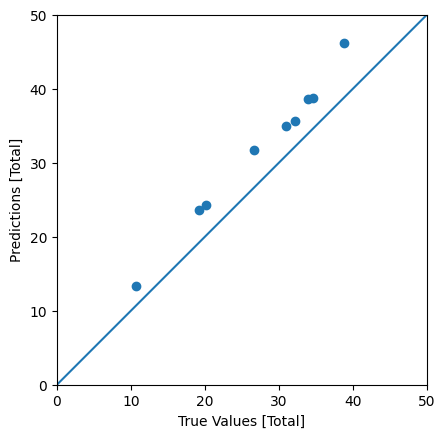

In [35]:
a = plt.axes(aspect='equal')
plt.scatter(y_test, test_predictions)
plt.xlabel('True Values [Total]')
plt.ylabel('Predictions [Total]')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

## Well, What If We Use Traditional Machine Learning 

In [36]:
from sklearn.ensemble import RandomForestRegressor

In [37]:
regr = RandomForestRegressor()

In [38]:
regr.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [39]:
regr.score(x_train, y_train)*100

99.99933175146552

In [40]:
regr.score(x_valid, y_valid)*100

99.99663698849568

In [41]:
regr.score(x_test, y_test)*100

99.99853318165248

In [42]:
test_predictions = regr.predict(x_test)

### Plot them

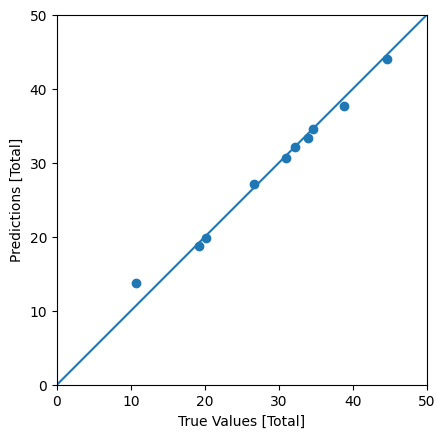

In [43]:
a = plt.axes(aspect='equal')
plt.scatter(y_test, test_predictions)
plt.xlabel('True Values [Total]')
plt.ylabel('Predictions [Total]')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)